In [ ]:
DATA_DIR = "/Users/diadora/Desktop/494-algo-representations/info_494_task_3"  

import os
PLOTS_DIR = os.path.join(DATA_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Data dir : {DATA_DIR}")
print(f"Plots dir: {PLOTS_DIR}")

Data dir : /Users/diadora/Desktop/494-algo-representations/info_494_task_3
Plots dir: /Users/diadora/Desktop/494-algo-representations/info_494_task_3/plots


In [2]:
import glob, re, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        130,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
})

PALETTE = {
    "CRH":   "#2ecc71",
    "CRNH":  "#e74c3c",
    "NMR":   "#95a5a6",
    "MISINFORMED_OR_POTENTIALLY_MISLEADING": "#e67e22",
    "NOT_MISLEADING":    "#3498db",
    "HELPFUL":           "#2ecc71",
    "SOMEWHAT_HELPFUL":  "#f39c12",
    "NOT_HELPFUL":       "#e74c3c",
    "ADD":       "#2ecc71",
    "REMOVE":    "#e74c3c",
    "SWAP":      "#e67e22",
    "NO_CHANGE": "#95a5a6",
}

STATUS_MAP = {
    "CURRENTLY_RATED_HELPFUL":     "CRH",
    "CURRENTLY_RATED_NOT_HELPFUL": "CRNH",
    "NEEDS_MORE_RATINGS":          "NMR",
}

URL_RE = re.compile(r'https?://[^\s\)\]\>\"\' ]+', re.IGNORECASE)
print("Imports OK")

Imports OK


In [ ]:
NOTE_COLS = [
    'noteId', 'participantId', 'createdAtMillis', 'tweetId',
    'classification', 'summary', 'isCollaborativeNote',
    'trustworthySources', 'isMediaNote',
]
note_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'notes-*.tsv')))
print(f'Notes files: {[os.path.basename(p) for p in note_paths]}')

dfs = []
for p in note_paths:
    header = pd.read_csv(p, sep='\t', nrows=0).columns.tolist()
    use    = [c for c in NOTE_COLS if c in header]
    dfs.append(pd.read_csv(p, sep='\t', low_memory=False, usecols=use))
    print(f'  Loaded {os.path.basename(p)}')

notes = pd.concat(dfs, ignore_index=True)
notes['created_at']   = pd.to_datetime(notes['createdAtMillis'], unit='ms', utc=True)
notes['created_date'] = notes['created_at'].dt.normalize()
notes['isCollaborativeNote'] = (
    pd.to_numeric(notes.get('isCollaborativeNote', 0), errors='coerce').fillna(0).astype(int)
)
print(f'\nTotal notes: {len(notes):,}')

cn = notes[notes['isCollaborativeNote'] == 1].copy()
COLLAB_IDS = set(cn['noteId'])
print(f'Collaborative notes : {len(cn):,}')
print(f'Unique tweets       : {cn["tweetId"].nunique():,}')
print(f'Date range          : {cn["created_date"].min().date()} → {cn["created_date"].max().date()}')

Notes files: ['notes-00000.tsv', 'notes-00001.tsv']
  Loaded notes-00000.tsv
  Loaded notes-00001.tsv

Total notes: 2,456,376
Collaborative notes : 8,283
Unique tweets       : 3,214
Date range          : 2026-01-21 → 2026-03-01


In [ ]:
# Ratings – loading one file for now
RATING_COLS = [
    'noteId', 'createdAtMillis', 'helpfulnessLevel',
    'helpful', 'notHelpful', 'helpfulGoodSources',
    'notHelpfulSourcesMissingOrUnreliable', 'notHelpfulIncorrect',
    'suggestion',
]
rating_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'ratings-*.tsv')))
p = rating_paths[0]  # just use the first file
print(f'Loading: {os.path.basename(p)}')

header = pd.read_csv(p, sep='\t', nrows=0).columns.tolist()
use    = [c for c in RATING_COLS if c in header]
ratings = pd.read_csv(p, sep='\t', low_memory=False, usecols=use)
ratings = ratings[ratings['noteId'].isin(COLLAB_IDS)].copy()
ratings['created_at']   = pd.to_datetime(ratings['createdAtMillis'], unit='ms', utc=True)
ratings['created_date'] = ratings['created_at'].dt.normalize()
print(f'Ratings loaded: {len(ratings):,}  (collab notes only)')

Loading: ratings-00000.tsv
Ratings loaded: 0  (collab notes only)


In [5]:
# Status history – filter to collab note IDs only
sh_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'noteStatusHistory-*.tsv')))
sh = pd.read_csv(sh_paths[0], sep='\t', low_memory=False)
sh = sh[sh['noteId'].isin(COLLAB_IDS)].copy()   # drop rows we don't need
sh['created_at'] = pd.to_datetime(sh['createdAtMillis'], unit='ms', utc=True)
sh['status_changed_at'] = pd.to_datetime(
    sh['timestampMillisOfMostRecentStatusChange'].replace(-1, pd.NA),
    unit='ms', utc=True
)
print(f'Status history rows (collab notes only): {len(sh):,}')

Status history rows (collab notes only): 6,521


In [ ]:
print(cn['currentStatus'].value_counts() if 'currentStatus' in cn.columns else 'Status not yet attached')
print(f'\nAll data loaded. Ready to analyse.')

Status not yet attached

All data loaded. Ready to analyse.


In [7]:
# Attach latest status to each collaborative note
latest_status = (
    sh.sort_values('status_changed_at', na_position='first')
    .groupby('noteId')['currentStatus'].last()
    .map(STATUS_MAP).fillna('UNKNOWN')
    .reset_index()
)
cn = cn.merge(latest_status, on='noteId', how='left')
cn['currentStatus'] = cn['currentStatus'].fillna('UNKNOWN')
print(cn['currentStatus'].value_counts())

currentStatus
NMR        6366
UNKNOWN    1762
CRNH         82
CRH          73
Name: count, dtype: int64


### Daily count of collaborative notes

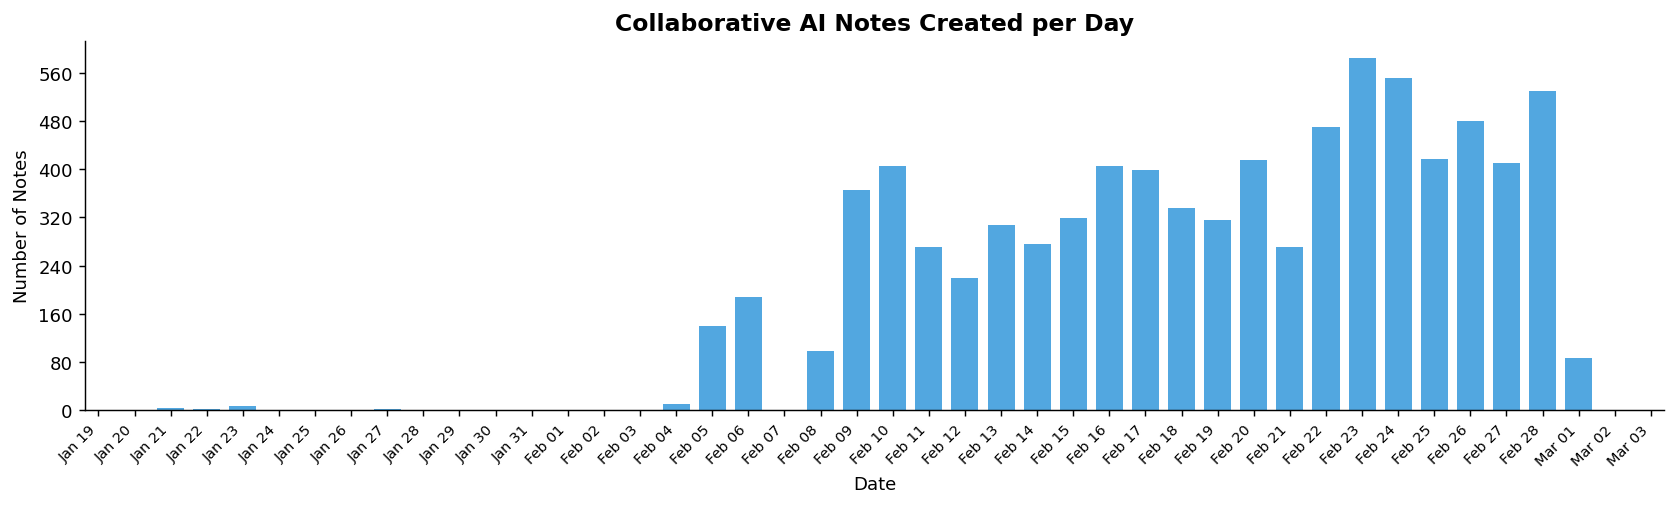

In [8]:
daily = cn.groupby('created_date').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(daily['created_date'], daily['count'], color='#3498db', alpha=0.85, width=pd.Timedelta('18h'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.set_title('Collaborative AI Notes Created per Day')
ax.set_xlabel('Date'); ax.set_ylabel('Number of Notes')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01a_collab_notes_per_day.png'), bbox_inches='tight')
plt.show()

### By status (CRH/CRNH/NMR)

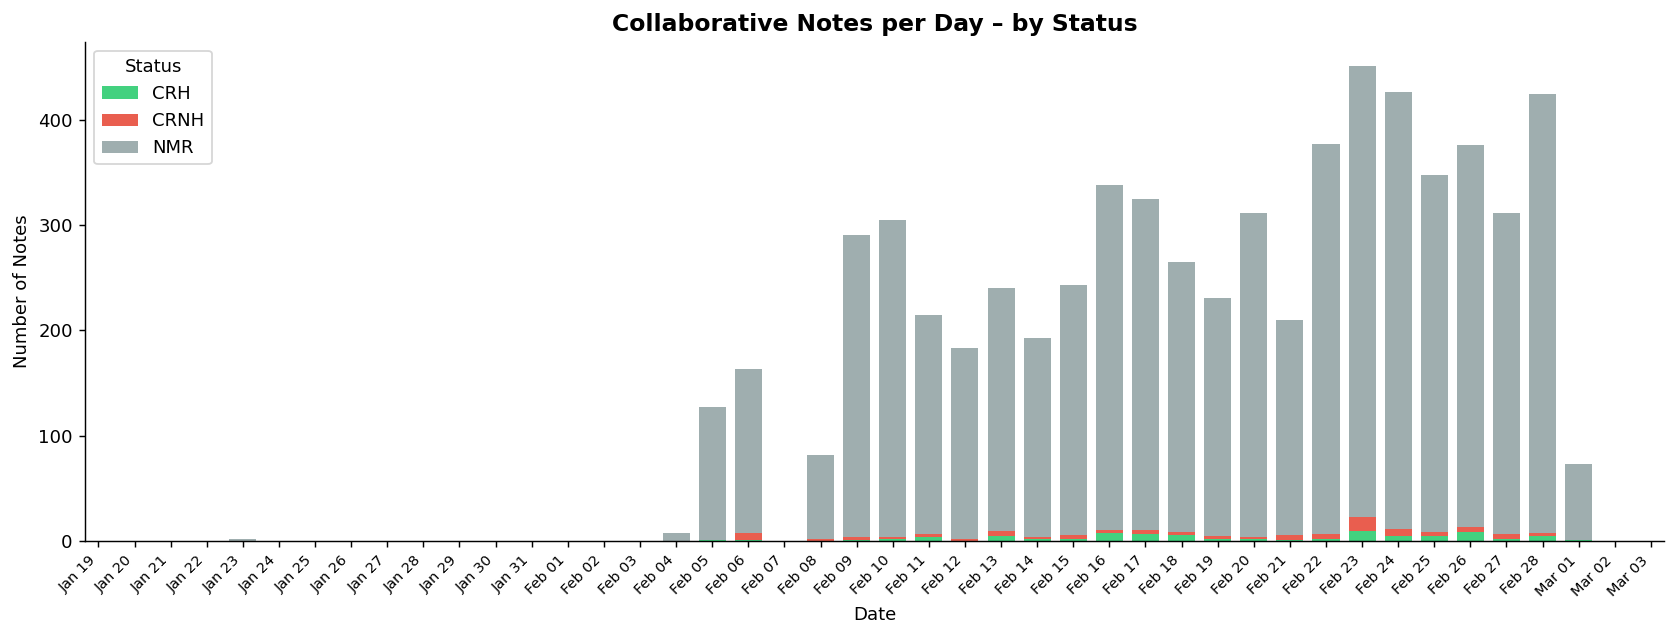

In [9]:
statuses = ['CRH', 'CRNH', 'NMR']
daily_s = (
    cn.groupby(['created_date', 'currentStatus']).size()
    .unstack(fill_value=0)
    .reindex(columns=[s for s in statuses if s in cn['currentStatus'].unique()], fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(daily_s))
for s in statuses:
    if s in daily_s.columns:
        ax.bar(daily_s.index, daily_s[s], bottom=bottom, label=s,
               color=PALETTE.get(s, '#aaa'), alpha=0.9, width=pd.Timedelta('18h'))
        bottom += daily_s[s].values
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.set_title('Collaborative Notes per Day – by Status')
ax.set_xlabel('Date'); ax.set_ylabel('Number of Notes')
ax.legend(title='Status', loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01b_by_status.png'), bbox_inches='tight')
plt.show()

### By classification

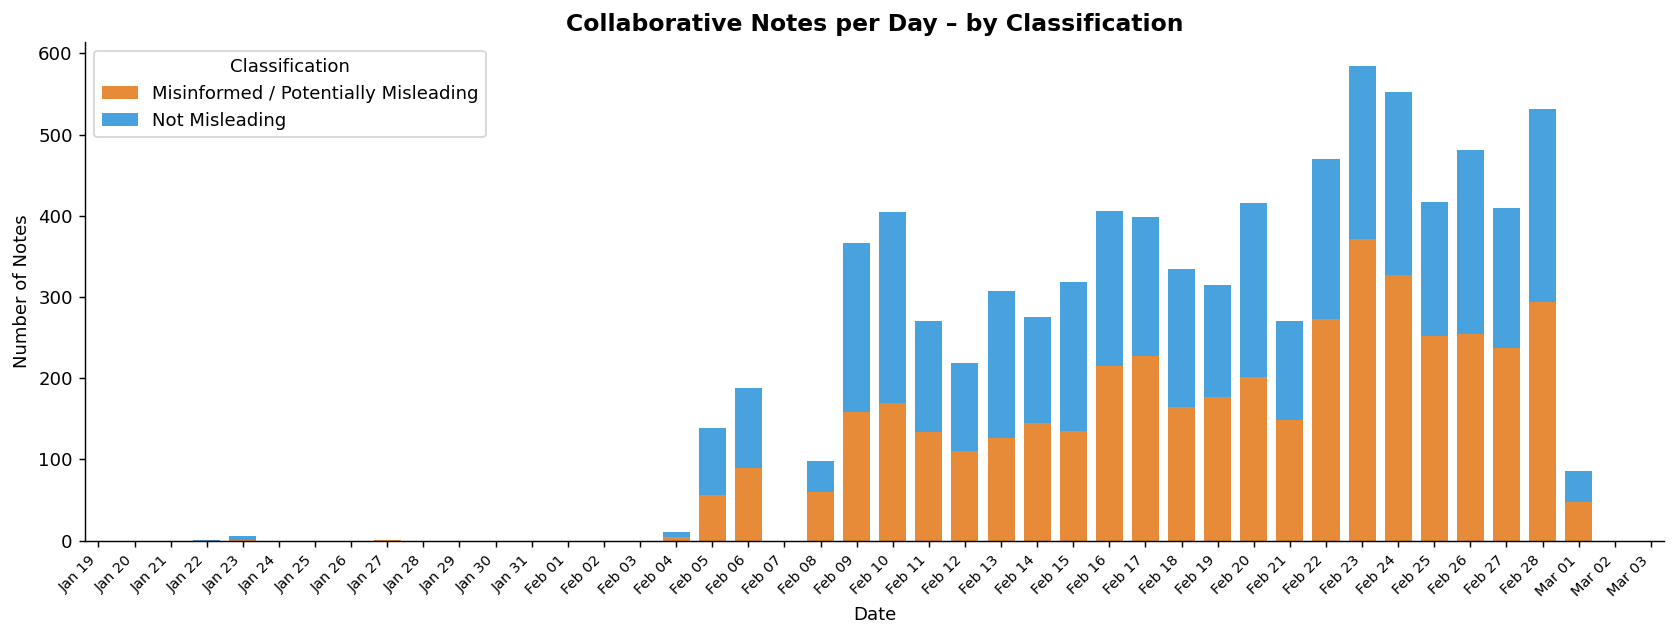

In [10]:
CLS_LABELS = {
    'MISINFORMED_OR_POTENTIALLY_MISLEADING': 'Misinformed / Potentially Misleading',
    'NOT_MISLEADING': 'Not Misleading',
}
cn['cls_clean'] = cn['classification'].fillna('UNKNOWN')
classes = [c for c in CLS_LABELS if c in cn['cls_clean'].unique()]

daily_c = (
    cn.groupby(['created_date', 'cls_clean']).size()
    .unstack(fill_value=0)
    .reindex(columns=classes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(daily_c))
for c in classes:
    if c in daily_c.columns:
        ax.bar(daily_c.index, daily_c[c], bottom=bottom,
               label=CLS_LABELS.get(c, c), color=PALETTE.get(c, '#aaa'),
               alpha=0.9, width=pd.Timedelta('18h'))
        bottom += daily_c[c].values
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.set_title('Collaborative Notes per Day – by Classification')
ax.set_xlabel('Date'); ax.set_ylabel('Number of Notes')
ax.legend(title='Classification', loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01c_by_classification.png'), bbox_inches='tight')
plt.show()

### Status & classification flips

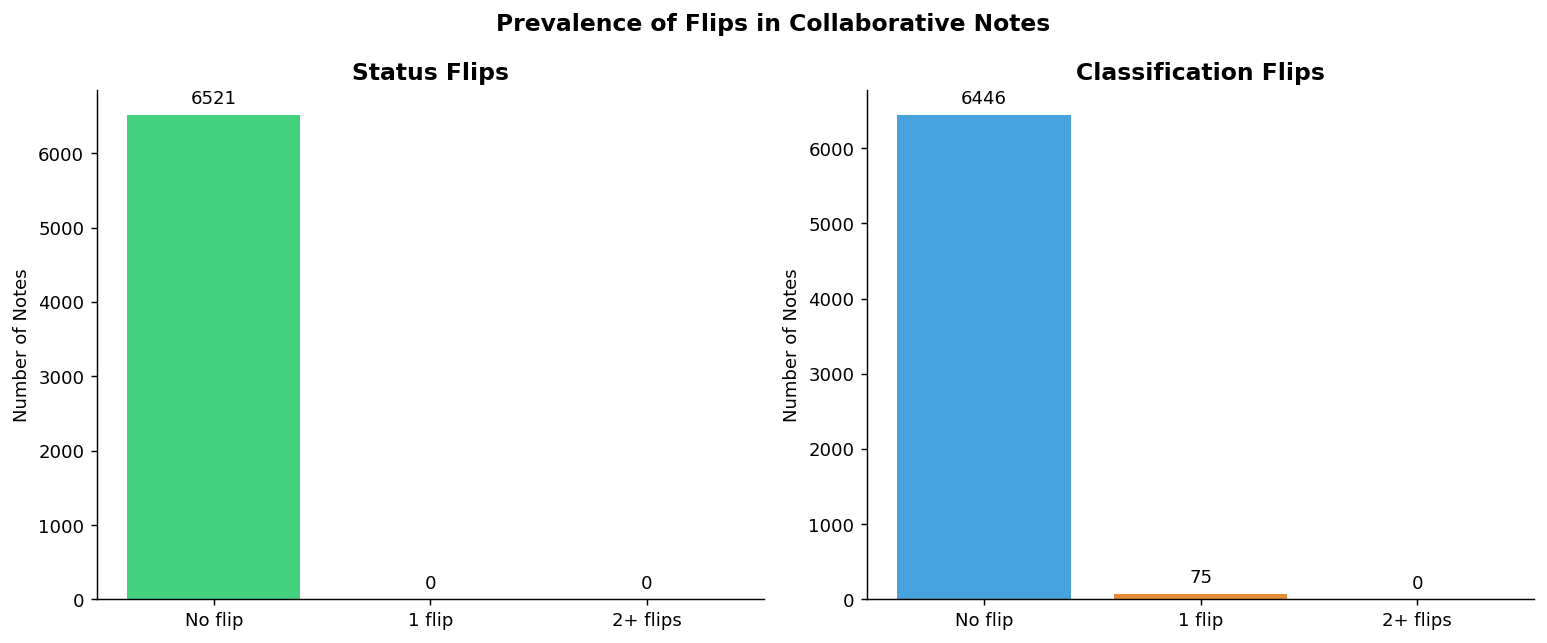

Notes with ≥1 status flip: 0.0%
Notes with cls flip:        1.2%


In [ ]:
cn_ids = set(cn['noteId'])
sh_cn  = sh[sh['noteId'].isin(cn_ids)].copy()
sh_cn  = sh_cn.sort_values(['noteId', 'status_changed_at'])
sh_cn['status_short'] = sh_cn['currentStatus'].map(STATUS_MAP).fillna('UNKNOWN')
sh_cn['prev_status']  = sh_cn.groupby('noteId')['status_short'].shift(1)
sh_cn['status_flip']  = (sh_cn['status_short'] != sh_cn['prev_status']) & sh_cn['prev_status'].notna()

flip_counts = sh_cn.groupby('noteId')['status_flip'].sum().reset_index(name='n_flips')
per = sh_cn.groupby('noteId').last().reset_index()
per = per.merge(flip_counts, on='noteId', how='left')
per['n_flips'] = per['n_flips'].fillna(0).astype(int)

# Classification flip, using whichever columns are actually present
has_first  = 'firstNonNMRStatus'  in per.columns
has_latest = 'latestNonNMRStatus' in per.columns

if has_first and has_latest:
    per['cls_flip'] = (
        per['firstNonNMRStatus'].notna() & per['latestNonNMRStatus'].notna() &
        (per['firstNonNMRStatus'] != per['latestNonNMRStatus'])
    )
elif has_first:
    per['cls_flip'] = (
        per['firstNonNMRStatus'].notna() &
        (per['firstNonNMRStatus'] != per['currentStatus'])
    )
else:
    per['cls_flip'] = False

cats     = ['No flip', '1 flip', '2+ flips']
s_vals   = [(per['n_flips']==0).sum(), (per['n_flips']==1).sum(), (per['n_flips']>=2).sum()]
cls_vals = [(~per['cls_flip']).sum(), per['cls_flip'].sum(), 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, vals, title, clrs in [
    (ax1, s_vals,   'Status Flips',        ['#2ecc71','#e67e22','#e74c3c']),
    (ax2, cls_vals, 'Classification Flips', ['#3498db','#e67e22','#e74c3c']),
]:
    bars = ax.bar(cats, vals, color=clrs, alpha=0.9)
    ax.bar_label(bars, padding=4, fontsize=10)
    ax.set_title(title); ax.set_ylabel('Number of Notes')
plt.suptitle('Prevalence of Flips in Collaborative Notes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01d_flips.png'), bbox_inches='tight')
plt.show()
print(f"Notes with ≥1 status flip: {(per['n_flips']>0).mean()*100:.1f}%")
print(f"Notes with cls flip:        {per['cls_flip'].mean()*100:.1f}%")

In [ ]:
# Build version table, sort by tweetId + time, assign version numbers
cn_v = cn.sort_values(['tweetId', 'createdAtMillis']).copy()
cn_v['version']     = cn_v.groupby('tweetId').cumcount() + 1
cn_v['is_revision'] = cn_v['version'] > 1

print(f"Tweets with ≥2 versions: {cn_v[cn_v['is_revision']]['tweetId'].nunique():,}")
print(f"Version distribution:")
print(cn_v.groupby('tweetId')['version'].max().value_counts().sort_index())

Tweets with ≥2 versions: 1,586
Version distribution:
version
1     1628
2      679
3      321
4      196
5      112
6       77
7       50
8       39
9       17
10      15
11      11
12       9
13       9
14      10
15       2
16       2
17       1
18       2
19       3
20       1
22       2
23       6
24       2
25       4
26       2
28       1
29       2
31       2
32       1
34       1
36       2
37       2
41       1
43       1
59       1
Name: count, dtype: int64


### Versions per tweet

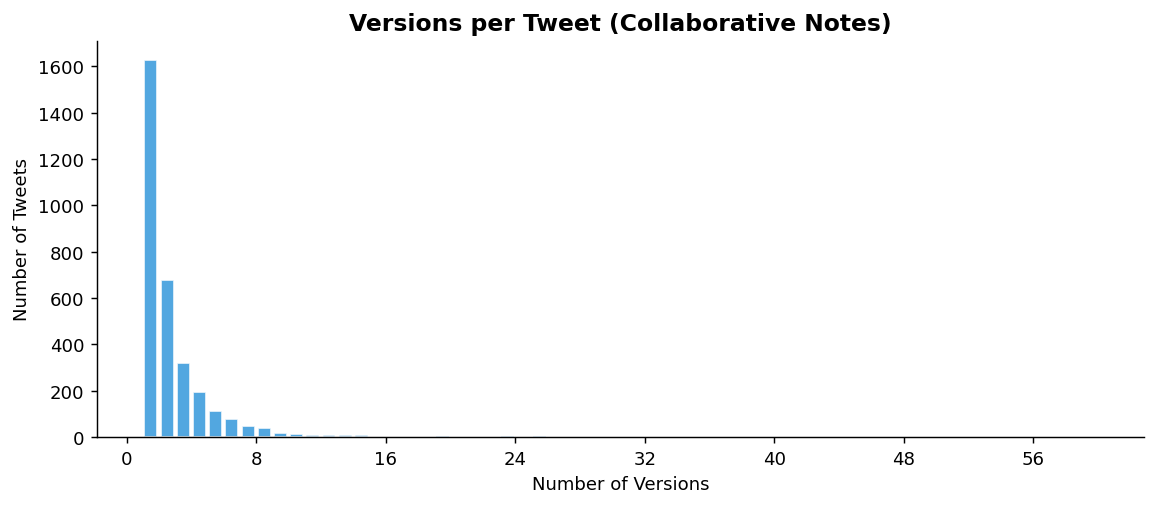

Median: 1.0  Max: 59


In [14]:
ver_counts = cn_v.groupby('tweetId')['version'].max()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ver_counts, bins=range(1, int(ver_counts.max())+2),
        color='#3498db', alpha=0.85, edgecolor='white', rwidth=0.8)
ax.set_xlabel('Number of Versions'); ax.set_ylabel('Number of Tweets')
ax.set_title('Versions per Tweet (Collaborative Notes)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02a_versions_per_tweet.png'), bbox_inches='tight')
plt.show()
print(f'Median: {ver_counts.median():.1f}  Max: {ver_counts.max()}')